In [42]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import librosa

In [43]:
# 1. Load Dataset
data_dir = "dataset"  # Folder dataset setelah diekstrak
commands = np.array(tf.io.gfile.listdir(data_dir))
commands = commands[commands != '_background_noise_']

# 2. Parameters
sample_rate = 16000  # Google Speech Commands menggunakan 16kHz
input_length = sample_rate  # 1 detik audio

In [44]:
# 3. Preprocessing: Convert .wav to log-mel spectrogram
def preprocess_audio(file_path):
    audio, _ = librosa.load(file_path, sr=sample_rate)
    audio = librosa.util.fix_length(audio, size=input_length)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=64, fmax=8000)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec.T  # Transpose for time-first format

In [45]:
# 4. Load validation and testing files
def load_split(file_path):
    with open(file_path, "r") as f:
        return [os.path.join(data_dir, line.strip()) for line in f.readlines()]

validation_files = load_split(os.path.join(data_dir, "validation_list.txt"))
testing_files = load_split(os.path.join(data_dir, "testing_list.txt"))

In [46]:
# 5. Create Dataset
def create_dataset(file_list, commands):
    filenames, labels = [], []
    for file in file_list:
        label = os.path.basename(os.path.dirname(file))
        if label in commands:
            filenames.append(file)
            labels.append(np.where(commands == label)[0][0])

    def generator():
        for file, label in zip(filenames, labels):
            yield preprocess_audio(file), label

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, 64), dtype=tf.float32),  # Log-Mel shape
            tf.TensorSpec(shape=(), dtype=tf.int32),
        ),
    )
    return dataset.shuffle(len(filenames)).repeat().batch(32).prefetch(tf.data.AUTOTUNE)

train_files = [
    os.path.join(root, file)
    for command in commands
    for root, _, files in os.walk(os.path.join(data_dir, command))
    for file in files if file.endswith(".wav")
    if file not in validation_files and file not in testing_files
]

train_dataset = create_dataset(train_files, commands)
val_dataset = create_dataset(validation_files, commands)

In [47]:
# 6. Build Model
def build_model():
    # Transformer-based Model
    inputs = layers.Input(shape=(None, 64), name="log_mel")
    
    x = layers.LayerNormalization(axis=-1)(inputs)
    x = layers.Conv1D(128, kernel_size=3, strides=1, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Transformer Encoder
    for _ in range(4):
        x1 = layers.LayerNormalization(axis=-1)(x)
        attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x1, x1)
        x = layers.Add()([x, attn_output])

        x2 = layers.LayerNormalization(axis=-1)(x)
        ffn_output = layers.Dense(128, activation="relu")(x2)
        ffn_output = layers.Dense(128)(ffn_output)
        x = layers.Add()([x, ffn_output])

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(len(commands), activation="softmax")(x)

    return models.Model(inputs, outputs)

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ log_mel             │ (None, None, 64)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ log_mel[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, None, 128) │     24,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, None, 128) │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ max_pooling1d_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 128) │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, None, 128) │          0 │ max_pooling1d_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, None, 128) │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, None, 128) │     16,512 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, None, 128) │          0 │ add_8[0][0],      │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 128) │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, None, 128) │          0 │ add_9[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, None, 128) │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, None, 128) │     16,512 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, None, 128) │          0 │ add_10[0][0],     │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 692,008 (2.64 MB)

 Trainable params: 692,008 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# 7. Train the Model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=len(train_files) // 32,  # Total batch per epoch
    validation_steps=len(validation_files) // 32,  # Validation batch per epoch
    epochs=15
)

# 8. Save the Model
model.save("speech_command_model.keras")

Epoch 1/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 717s 123ms/step - accuracy: 0.5688 - loss: 1.5698 - val_accuracy: 0.8278 - val_loss: 0.5758
Epoch 2/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 382s 116ms/step - accuracy: 0.8360 - loss: 0.5624 - val_accuracy: 0.8969 - val_loss: 0.3334
Epoch 3/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 368s 111ms/step - accuracy: 0.8712 - loss: 0.4370 - val_accuracy: 0.9183 - val_loss: 0.2741
Epoch 4/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 361s 109ms/step - accuracy: 0.8933 - loss: 0.3570 - val_accuracy: 0.9154 - val_loss: 0.2707
Epoch 5/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 369s 111ms/step - accuracy: 0.9063 - loss: 0.3135 - val_accuracy: 0.9358 - val_loss: 0.2105
Epoch 6/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 365s 111ms/step - accuracy: 0.9184 - loss: 0.2678 - val_accuracy: 0.9406 - val_loss: 0.1877
Epoch 7/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 380s 115ms/step - accuracy: 0.9267 - loss: 0.2403 - val_accuracy: 0.9451 - val_loss: 0.1732
Epoch 8/15
3307/3307 ━━━━━━━━━━━━━━━━━━━━ 428s 129ms/step - ac

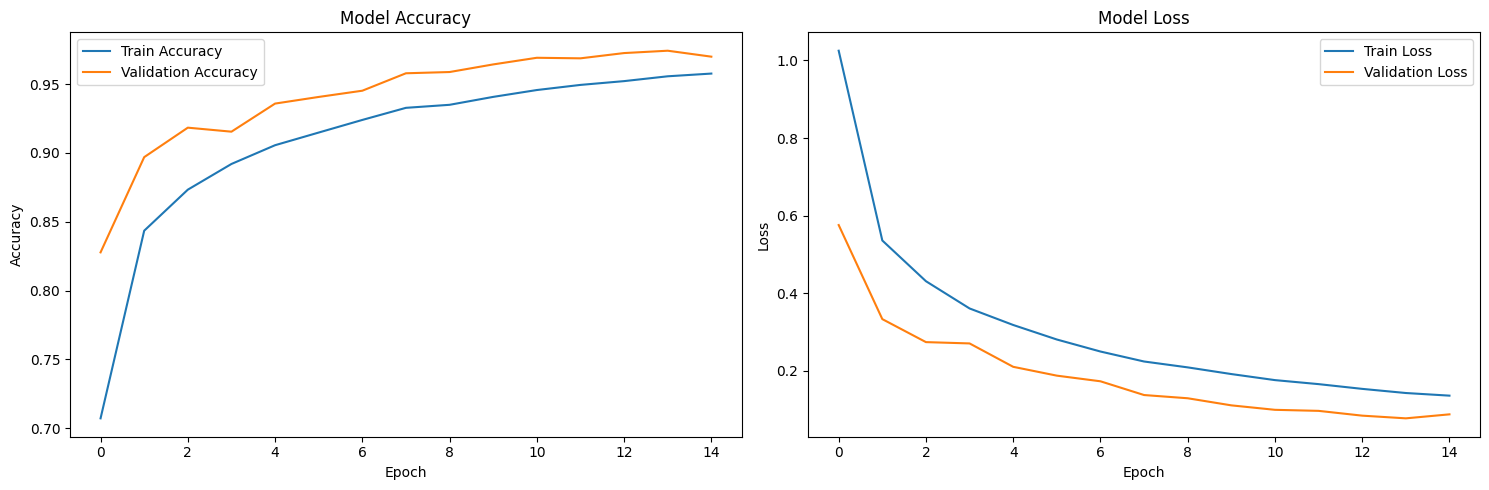

In [53]:
import matplotlib.pyplot as plt

# Plot grafik akurasi dan loss
plt.figure(figsize=(15, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [54]:
# 9. Test the Model
def predict_command(file_path):
    log_mel_spec = preprocess_audio(file_path)
    log_mel_spec = np.expand_dims(log_mel_spec, axis=0)  # Add batch dimension
    prediction = model.predict(log_mel_spec)
    return commands[np.argmax(prediction)]

# Example Usage:
print(predict_command("test/audio/0a2b400e_nohash_1.wav"))
print(predict_command("test/audio/0a196374_nohash_2.wav"))
print(predict_command("test/audio/0b7ee1a0_nohash_2.wav"))
print(predict_command("test/audio/0b77ee66_nohash_0.wav"))
print(predict_command("test/audio/0c2ca723_nohash_0.wav"))
print(predict_command("test/audio/0a2b400e_nohash_0.wav"))
print(predict_command("test/audio/0a2b400e_nohash_3.wav"))
print(predict_command("test/audio/0ac15fe9_nohash_2.wav"))
print(predict_command("test/audio/0b7ee1a0_nohash_22.wav"))
print(predict_command("test/audio/0b09edd3_nohash_0.wav"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
no
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
stop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
right
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
bird
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
yes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
wow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
visual
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
on
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
follow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
happy


In [50]:
from moviepy import VideoFileClip
from pydub import AudioSegment

def extract_audio(video_file, audio_file, sample_rate=16000):
    # Memuat video
    video = VideoFileClip(video_file)
    
    # Mengambil audio dari video
    audio = video.audio
    # Menyimpan audio sementara dalam format WAV
    temp_audio_file = 'temp_audio.wav'
    audio.write_audiofile(temp_audio_file)
    
    # Menutup objek audio dan video
    audio.close()
    video.close()
    
    # Menggunakan pydub untuk mengubah sample rate
    audio_segment = AudioSegment.from_wav(temp_audio_file)
    
    # Mengubah sample rate menjadi yang diinginkan
    audio_segment = audio_segment.set_frame_rate(sample_rate)
    
    # Menyimpan audio dengan sample rate yang baru
    audio_segment.export(audio_file, format="wav")

# Mengonversi video dengan sample rate 16 kHz
extract_audio('testfull.mp4', 'test.wav', sample_rate=16000)

{'video_found': True, 'audio_found': True, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'https://clipchamp.com', 'comment': 'Create videos with https://clipchamp.com/en/video-editor - free online video editor, video compressor, video converter.'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1440, 1080], 'bitrate': 16, 'fps': 30.0, 'codec_name': 'h264', 'profile': '(Main)', 'metadata': {'handler_name': 'VideoHandler'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': None, 'default': True, 'fps': 48000, 'bitrate': 192, 'metadata': {'handler_name': 'SoundHandler'}}], 'input_number': 0}], 'duration': 10.04, 'bitrate': 217, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(Main)', 'video_size': [1440, 1080], 'video_bitrate': 16, 'vid

MoviePy - Done.


In [51]:
# 10. Detect Words in Continuous Audio

def detect_words_in_sentence(audio_path, window_size=1.0, stride=1.0):
    
    # Load the audio file
    audio, sr = librosa.load(audio_path, sr=sample_rate)

    # Calculate the number of samples for the window and stride
    window_samples = int(window_size * sr)
    stride_samples = int(stride * sr)

    # Initialize list for results
    detected_words = []

    # Slide the window over the audio
    for start in range(0, len(audio) - window_samples + 1, stride_samples):
        end = start + window_samples
        segment = audio[start:end]

        # Ensure the segment has the correct length
        segment = librosa.util.fix_length(segment, size=window_samples)

        # Convert to log-mel spectrogram
        log_mel_spec = librosa.feature.melspectrogram(y=segment, sr=sample_rate, n_mels=64, fmax=8000)
        log_mel_spec = librosa.power_to_db(log_mel_spec, ref=np.max).T

        # Add batch dimension
        log_mel_spec = np.expand_dims(log_mel_spec, axis=0)

        # Predict the word
        prediction = model.predict(log_mel_spec)
        predicted_label = commands[np.argmax(prediction)]

        # Skip background or silence prediction
        if predicted_label != "silence":
            detected_words.append(predicted_label)

    # Join detected words into a sentence-like string
    return " ".join(detected_words)

# Example Usage
sentence_audio_path = "test.wav"
detected_sentence = detect_words_in_sentence(sentence_audio_path)

print("Detected sentence:")
print(detected_sentence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Detected sentence:
no stop right bird yes wow visual on follow happy


In [52]:
# Translate detected sentence to Indonesian
from googletrans import Translator

translator = Translator()
translation = translator.translate(detected_sentence, src="en", dest="id").text

print("Translation to Indonesian:")
print(translation)


Translation to Indonesian:
Tidak Hentikan Burung Benar Ya Wow Visual di Follow Happy
